In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache

cache_dir = "./allen_vbn_cache"
os.makedirs(cache_dir, exist_ok=True)

cache = VisualBehaviorNeuropixelsProjectCache.from_s3_cache(cache_dir=cache_dir)

processed_file = "./processed_vbn_session_1108334384.npz"

In [2]:
sessions = cache.get_ecephys_session_table()
print("Total sessions:", len(sessions))

units = cache.get_unit_table()
print("Total units:", len(units))

Total sessions: 103
Total units: 319013


In [3]:
target_regions = ['VISp', 'VISl', 'VISrl', 'VISam', 'VISpm', 'VISal', 'LGd', 'LP']
region_counts = units.loc[units['structure_acronym'].isin(target_regions), 'structure_acronym'].value_counts()
print(region_counts)
print("Total units in target regions:", region_counts.sum())

VISp     21567
VISpm    19772
VISl     19525
VISal    17442
VISam    16938
VISrl    15319
LP        5479
LGd       3866
Name: structure_acronym, dtype: int64
Total units in target regions: 119908


In [4]:
global_target_units = units[units['structure_acronym'].isin(target_regions)].copy()
session_region_counts = global_target_units.groupby(['ecephys_session_id', 'structure_acronym']).size().unstack(fill_value=0)

good_sessions = session_region_counts[
    (session_region_counts.get('VISp', 0) > 20) &
    (session_region_counts.get('LGd', 0) > 20)
]

print("Sessions meeting VISp/LGd threshold:", len(good_sessions))

Sessions meeting VISp/LGd threshold: 57


In [5]:
selected_sessions = [1108334384, 1087723305, 1043752325]

session = cache.get_ecephys_session(ecephys_session_id=selected_sessions[0])

/home/ntsipouria/.local/lib/python3.11/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


In [6]:
trials = session.trials
print("Total trials:", len(trials))

Total trials: 607


In [7]:
print(trials[['hit', 'miss', 'false_alarm', 'correct_reject']].sum())

hit               108
miss              172
false_alarm         2
correct_reject     38
dtype: int64


In [8]:
session_units = session.get_units()
print("Total units in this session:", len(session_units))

Total units in this session: 1846


In [9]:
unit_regions = units[['structure_acronym']].copy()
session_units_with_regions = session_units.join(unit_regions, how='left')
target_regions = ['VISp', 'VISl', 'VISrl', 'VISam', 'VISpm', 'VISal', 'LGd', 'LP']
session_units_filtered = session_units_with_regions[
    (session_units_with_regions['quality'] == 'good') &
    (session_units_with_regions['structure_acronym'].isin(target_regions))
].copy()

print(f"Good units in target regions: {len(session_units_filtered)}")
print(session_units_filtered['structure_acronym'].value_counts())

Good units in target regions: 1072
VISp     200
VISpm    165
VISrl    149
VISal    145
VISl     133
LGd      108
VISam    106
LP        66
Name: structure_acronym, dtype: int64


In [10]:
change_trials = trials[(trials['hit'] == True) | (trials['miss'] == True)].copy()
change_trials['outcome'] = change_trials['hit'].map({True: 'hit', False: 'miss'})

print(f"Change trials: {len(change_trials)}")
print(change_trials['outcome'].value_counts())
print(change_trials[['start_time', 'change_time_no_display_delay', 'outcome']].head())

Change trials: 280
miss    172
hit     108
Name: outcome, dtype: int64
           start_time  change_time_no_display_delay outcome
trials_id                                                  
9            75.29062                      79.79517    miss
10           84.29801                      88.05151     hit
11           92.55515                      99.31106     hit
13          106.81732                     111.32115     hit
15          116.57550                     123.33102     hit


In [11]:
bin_size = 0.05  
window_start = -1.0  
window_end = 1.0    
bins = np.arange(window_start, window_end + bin_size, bin_size)
n_bins = len(bins) - 1
spike_times = session.spike_times
unit_ids = session_units_filtered.index.values
change_times = change_trials['change_time_no_display_delay'].values
print(f"Building firing rate matrix: {len(change_trials)} trials x {len(unit_ids)} units x {n_bins} bins")

firing_rates = np.zeros((len(change_times), len(unit_ids), n_bins))

for i, ct in enumerate(change_times):
    if np.isnan(ct):
        continue
    for j, uid in enumerate(unit_ids):
        spikes = spike_times[uid]
       
        relative_spikes = spikes - ct
        counts, _ = np.histogram(relative_spikes, bins=bins)
        firing_rates[i, j, :] = counts / bin_size  

print(f"Firing rate matrix shape: {firing_rates.shape}")
print(f"(trials, units, time_bins)")

Building firing rate matrix: 280 trials x 1072 units x 40 bins
Firing rate matrix shape: (280, 1072, 40)
(trials, units, time_bins)


We aligned spike times to the stimulus change and converted them into firing rates using 50 ms bins from -1 to +1 seconds around the change.

In [12]:
trial_labels = change_trials["outcome"].values
trial_labels_binary = change_trials["hit"].values.astype(int)
brain_regions = session_units_filtered["structure_acronym"].values
bin_centers = bins[:-1] + bin_size / 2

In [13]:
np.savez(
    processed_file,
    firing_rates=firing_rates,
    trial_labels=trial_labels,
    trial_labels_binary=trial_labels_binary,
    brain_regions=brain_regions,
    unit_ids=unit_ids,
    bin_centers=bin_centers,
    bin_size=np.array(bin_size),
)
print(f"Saved to {processed_file}")

Saved to ./processed_vbn_session_1108334384.npz


In [14]:
data = np.load(processed_file, allow_pickle=True)
print("Saved keys:", data.files)
print("firing_rates shape:", data["firing_rates"].shape)

Saved keys: ['firing_rates', 'trial_labels', 'trial_labels_binary', 'brain_regions', 'unit_ids', 'bin_centers', 'bin_size']
firing_rates shape: (280, 1072, 40)


## Some Graphs 

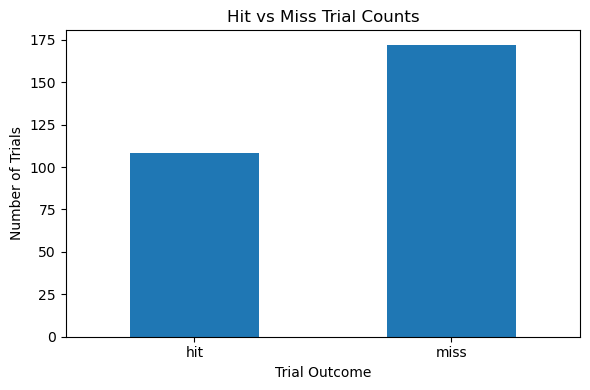

In [15]:
trial_count_df = pd.Series(trial_labels).value_counts().reindex(["hit", "miss"])

plt.figure(figsize=(6, 4))
trial_count_df.plot(kind="bar")
plt.title("Hit vs Miss Trial Counts")
plt.xlabel("Trial Outcome")
plt.ylabel("Number of Trials")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

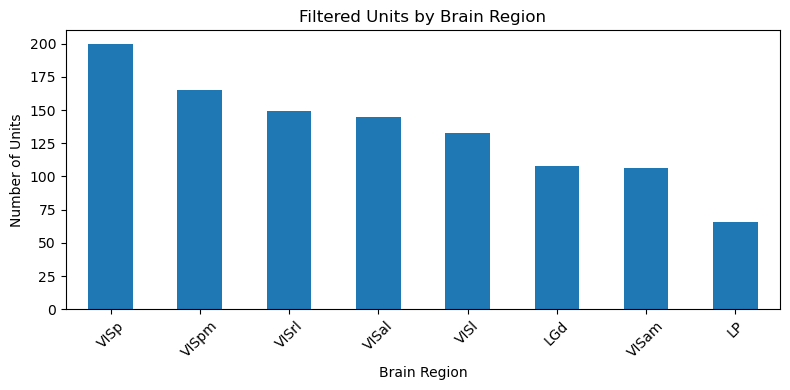

In [16]:
region_count_df = pd.Series(brain_regions).value_counts()

plt.figure(figsize=(8, 4))
region_count_df.plot(kind="bar")
plt.title("Filtered Units by Brain Region")
plt.xlabel("Brain Region")
plt.ylabel("Number of Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

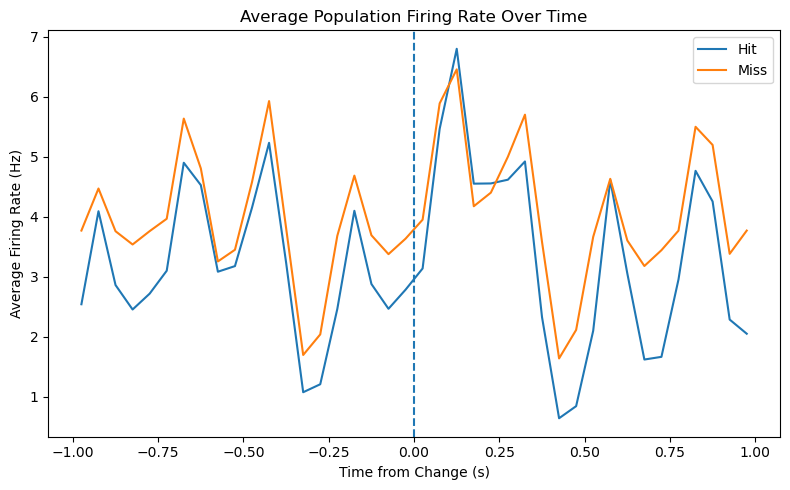

In [17]:
hit_mask = trial_labels == "hit"
miss_mask = trial_labels == "miss"

hit_mean = firing_rates[hit_mask].mean(axis=(0, 1))
miss_mean = firing_rates[miss_mask].mean(axis=(0, 1))

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, hit_mean, label="Hit")
plt.plot(bin_centers, miss_mean, label="Miss")
plt.axvline(0, linestyle="--")
plt.title("Average Population Firing Rate Over Time")
plt.xlabel("Time from Change (s)")
plt.ylabel("Average Firing Rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
import torch
import cebra
from cebra import CEBRA

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [19]:
from sklearn.model_selection import StratifiedShuffleSplit

time_mask = (bin_centers >= -0.20) & (bin_centers <= 0.15)
sel_times = bin_centers[time_mask]

X_trials = firing_rates[:, :, time_mask]
y_trials = trial_labels_binary.copy()

outer = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=0)
trainval_idx, test_idx = next(outer.split(np.zeros(len(y_trials)), y_trials))

y_trainval = y_trials[trainval_idx]

inner = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
train_idx_rel, val_idx_rel = next(inner.split(np.zeros(len(y_trainval)), y_trainval))

print("sel_times:", sel_times.shape)
print("X_trials:", X_trials.shape)
print("trainval_idx:", trainval_idx.shape)
print("test_idx:", test_idx.shape)
print("train_idx_rel:", train_idx_rel.shape)
print("val_idx_rel:", val_idx_rel.shape)

sel_times: (7,)
X_trials: (280, 1072, 7)
trainval_idx: (224,)
test_idx: (56,)
train_idx_rel: (168,)
val_idx_rel: (56,)


In [20]:
from sklearn.preprocessing import StandardScaler

X_trainval_trials = X_trials[trainval_idx]
X_test_trials = X_trials[test_idx]

X_train_trials = X_trainval_trials[train_idx_rel]
X_val_trials = X_trainval_trials[val_idx_rel]

n_train, n_neurons, n_sel_bins = X_train_trials.shape
n_val = X_val_trials.shape[0]
n_test = X_test_trials.shape[0]

X_train_bins = X_train_trials.transpose(0, 2, 1).reshape(-1, n_neurons)
X_val_bins = X_val_trials.transpose(0, 2, 1).reshape(-1, n_neurons)
X_test_bins = X_test_trials.transpose(0, 2, 1).reshape(-1, n_neurons)

scaler = StandardScaler()
X_train_bins_z = scaler.fit_transform(X_train_bins)
X_val_bins_z = scaler.transform(X_val_bins)
X_test_bins_z = scaler.transform(X_test_bins)

print("X_train_bins_z:", X_train_bins_z.shape)
print("X_val_bins_z:", X_val_bins_z.shape)
print("X_test_bins_z:", X_test_bins_z.shape)

X_train_bins_z: (1176, 1072)
X_val_bins_z: (392, 1072)
X_test_bins_z: (392, 1072)


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

# Original hit/miss labels split the same way as before
y_trials = trial_labels_binary.copy()

y_trainval = y_trials[trainval_idx]
y_test = y_trials[test_idx]

y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print("train hit/miss counts:", np.unique(y_train, return_counts=True))
print("val hit/miss counts:", np.unique(y_val, return_counts=True))
print("test hit/miss counts:", np.unique(y_test, return_counts=True))


def average_bins_back_to_trials(Z_bins, n_trials, n_sel_bins):
    return Z_bins.reshape(n_trials, n_sel_bins, -1).mean(axis=1)


def choose_best_k(X_train, y_train, X_val, y_val, k_list=None, metric="cosine"):
    if k_list is None:
        k_list = [1, 3, 5, 7, 9, 11, 15, 21]

    best_k = None
    best_score = -np.inf
    scores = {}

    for k in k_list:
        clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
        clf.fit(X_train, y_train)
        pred_val = clf.predict(X_val)
        score = balanced_accuracy_score(y_val, pred_val)
        scores[k] = score

        if score > best_score:
            best_score = score
            best_k = k

    print("k validation scores:", scores)
    print("best k:", best_k, "best val bal acc:", best_score)
    return best_k, scores

y_train shape: (168,)
y_val shape: (56,)
y_test shape: (56,)
train hit/miss counts: (array([0, 1]), array([103,  65]))
val hit/miss counts: (array([0, 1]), array([35, 21]))
test hit/miss counts: (array([0, 1]), array([34, 22]))


In [22]:
# --- Rebuild image labels + split-specific image labels ----------------------

# 1) Encode image identity from change_image_name
image_names = change_trials["change_image_name"].values
unique_images = np.unique(image_names)
image_to_int = {name: i for i, name in enumerate(unique_images)}
image_labels = np.array([image_to_int[n] for n in image_names])

print("Unique change images:", len(unique_images))
print("Image label mapping:")
for name, idx in image_to_int.items():
    print(f"  {idx}: {name}")

# 2) Trial-level image labels for each split
img_trainval = image_labels[trainval_idx]
img_test = image_labels[test_idx]
img_train = img_trainval[train_idx_rel]
img_val = img_trainval[val_idx_rel]

# 3) Bin-level image labels
n_sel_bins = sel_times.shape[0]
img_train_bins = np.repeat(img_train, n_sel_bins)
img_val_bins = np.repeat(img_val, n_sel_bins)
img_test_bins = np.repeat(img_test, n_sel_bins)

print("img_train shape:", img_train.shape)
print("img_val shape:", img_val.shape)
print("img_test shape:", img_test.shape)

print("img_train_bins shape:", img_train_bins.shape)
print("img_val_bins shape:", img_val_bins.shape)
print("img_test_bins shape:", img_test_bins.shape)

print("Image label distribution in train:", np.unique(img_train_bins, return_counts=True))

Unique change images: 8
Image label mapping:
  0: im012_r
  1: im036_r
  2: im044_r
  3: im047_r
  4: im078_r
  5: im083_r
  6: im111_r
  7: im115_r
img_train shape: (168,)
img_val shape: (56,)
img_test shape: (56,)
img_train_bins shape: (1176,)
img_val_bins shape: (392,)
img_test_bins shape: (392,)
Image label distribution in train: (array([0, 1, 2, 3, 4, 5, 6, 7]), array([133, 161, 161, 133, 147, 147, 161, 133]))


In [23]:
cebra_img = CEBRA(
    model_architecture="offset10-model",
    batch_size=256,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=3000,
    distance="cosine",
    conditional="time_delta",
    time_offsets=5,
    device=DEVICE,
    verbose=True,
)

cebra_img.fit(X_train_bins_z, img_train_bins)
print("CEBRA image-identity model trained!")

pos: -0.9995 neg:  5.6423 total:  4.6428 temperature:  1.0000: 100%|██████████| 3000/3000 [00:21<00:00, 140.76it/s]

CEBRA image-identity model trained!


In [24]:
# --- Transform all splits ----------------------------------------------------

Z_train_img = cebra_img.transform(X_train_bins_z)
Z_val_img = cebra_img.transform(X_val_bins_z)
Z_test_img = cebra_img.transform(X_test_bins_z)

n_train_trials = len(y_train)
n_val_trials = len(y_val)
n_test_trials = len(y_test)

Z_train_img_trial = average_bins_back_to_trials(Z_train_img, n_train_trials, n_sel_bins)
Z_val_img_trial = average_bins_back_to_trials(Z_val_img, n_val_trials, n_sel_bins)
Z_test_img_trial = average_bins_back_to_trials(Z_test_img, n_test_trials, n_sel_bins)

print(f"Trial-level embeddings: train={Z_train_img_trial.shape}, val={Z_val_img_trial.shape}, test={Z_test_img_trial.shape}")

Trial-level embeddings: train=(168, 8), val=(56, 8), test=(56, 8)


In [25]:
# --- Image identity decoding (paper-analogous metric) -----------------------

best_k_img, _ = choose_best_k(
    Z_train_img_trial, img_train,
    Z_val_img_trial, img_val,
    metric="cosine"
)

clf_img = KNeighborsClassifier(n_neighbors=best_k_img, metric="cosine")
clf_img.fit(Z_train_img_trial, img_train)
pred_img = clf_img.predict(Z_test_img_trial)

img_acc = balanced_accuracy_score(img_test, pred_img)

print(f"Image-identity decoding accuracy (CEBRA + kNN): {img_acc:.3f}")
print(f"Chance level: {1/len(unique_images):.3f}")


# PCA baseline on the SAME z-scored neural features
pca = PCA(n_components=8, random_state=0)

pca_train_bins = pca.fit_transform(X_train_bins_z)
pca_val_bins = pca.transform(X_val_bins_z)
pca_test_bins = pca.transform(X_test_bins_z)

pca_train = average_bins_back_to_trials(pca_train_bins, len(img_train), n_sel_bins)
pca_val = average_bins_back_to_trials(pca_val_bins, len(img_val), n_sel_bins)
pca_test = average_bins_back_to_trials(pca_test_bins, len(img_test), n_sel_bins)

best_k_pca_img, _ = choose_best_k(
    pca_train, img_train,
    pca_val, img_val,
    metric="cosine"
)

clf_pca_img = KNeighborsClassifier(n_neighbors=best_k_pca_img, metric="cosine")
clf_pca_img.fit(pca_train, img_train)
pred_pca_img = clf_pca_img.predict(pca_test)

pca_img_acc = balanced_accuracy_score(img_test, pred_pca_img)

print(f"Image-identity decoding accuracy (PCA + kNN): {pca_img_acc:.3f}")

k validation scores: {1: 0.4168154761904762, 3: 0.4182043650793651, 5: 0.4182043650793651, 7: 0.4182043650793651, 9: 0.4182043650793651, 11: 0.4182043650793651, 15: 0.4182043650793651, 21: 0.4182043650793651}
best k: 3 best val bal acc: 0.4182043650793651
Image-identity decoding accuracy (CEBRA + kNN): 0.592
Chance level: 0.125
k validation scores: {1: 0.7874007936507936, 3: 0.8078869047619047, 5: 0.6765376984126984, 7: 0.6095734126984127, 9: 0.6788194444444444, 11: 0.6952876984126984, 15: 0.6604662698412698, 21: 0.533234126984127}
best k: 3 best val bal acc: 0.8078869047619047
Image-identity decoding accuracy (PCA + kNN): 0.631


In [26]:
# --- Post-hoc hit/miss analysis on image-trained embedding ------------------

best_k_hm, _ = choose_best_k(
    Z_train_img_trial, y_train,
    Z_val_img_trial, y_val,
    metric="cosine"
)

clf_hm = KNeighborsClassifier(n_neighbors=best_k_hm, metric="cosine")
clf_hm.fit(Z_train_img_trial, y_train)

pred_hm = clf_hm.predict(Z_test_img_trial)
prob_hm = clf_hm.predict_proba(Z_test_img_trial)[:, 1]

hm_acc = balanced_accuracy_score(y_test, pred_hm)
hm_auroc = roc_auc_score(y_test, prob_hm)

print("Post-hoc hit/miss decoding from image embedding:")
print(f"  Balanced accuracy: {hm_acc:.3f}")
print(f"  AUROC: {hm_auroc:.3f}")

k validation scores: {1: 0.35238095238095235, 3: 0.36666666666666664, 5: 0.3476190476190476, 7: 0.3952380952380952, 9: 0.3333333333333333, 11: 0.37142857142857144, 15: 0.4238095238095238, 21: 0.45238095238095233}
best k: 21 best val bal acc: 0.45238095238095233
Post-hoc hit/miss decoding from image embedding:
  Balanced accuracy: 0.517
  AUROC: 0.553


In [27]:
# --- Results table ----------------------------------------------------------

rows = []

# Add existing earlier results only if they already exist
if "pred_raw" in globals() and "prob_raw" in globals():
    rows.append({
        "model": "Raw + kNN",
        "hit_miss_acc": balanced_accuracy_score(y_test, pred_raw),
        "hit_miss_auroc": roc_auc_score(y_test, prob_raw),
    })

if "pred_pca" in globals() and "prob_pca" in globals():
    rows.append({
        "model": "PCA + kNN",
        "hit_miss_acc": balanced_accuracy_score(y_test, pred_pca),
        "hit_miss_auroc": roc_auc_score(y_test, prob_pca),
    })

if "pred_time" in globals() and "prob_time" in globals():
    rows.append({
        "model": "CEBRA-Time + kNN",
        "hit_miss_acc": balanced_accuracy_score(y_test, pred_time),
        "hit_miss_auroc": roc_auc_score(y_test, prob_time),
    })

if "pred_beh" in globals() and "prob_beh" in globals():
    rows.append({
        "model": "CEBRA-Behavior (hit/miss) + kNN",
        "hit_miss_acc": balanced_accuracy_score(y_test, pred_beh),
        "hit_miss_auroc": roc_auc_score(y_test, prob_beh),
    })

if "pred_shuf" in globals() and "prob_shuf" in globals():
    rows.append({
        "model": "CEBRA-Behavior shuffled + kNN",
        "hit_miss_acc": balanced_accuracy_score(y_test, pred_shuf),
        "hit_miss_auroc": roc_auc_score(y_test, prob_shuf),
    })

# Add the new image-trained post-hoc result
rows.append({
    "model": "CEBRA-Image (post-hoc h/m) + kNN",
    "hit_miss_acc": hm_acc,
    "hit_miss_auroc": hm_auroc,
})

# Add image-identity decoding metrics too
rows.append({
    "model": "CEBRA-Image identity + kNN",
    "hit_miss_acc": img_acc,
    "hit_miss_auroc": np.nan,
})

rows.append({
    "model": "PCA-Image identity + kNN",
    "hit_miss_acc": pca_img_acc,
    "hit_miss_auroc": np.nan,
})

results_df = pd.DataFrame(rows)
display(results_df)

,model,hit_miss_acc,hit_miss_auroc
0,CEBRA-Image (post-hoc h/m) + kNN,0.517380,0.552807
1,CEBRA-Image identity + kNN,0.591518,NaN
2,PCA-Image identity + kNN,0.630952,NaN


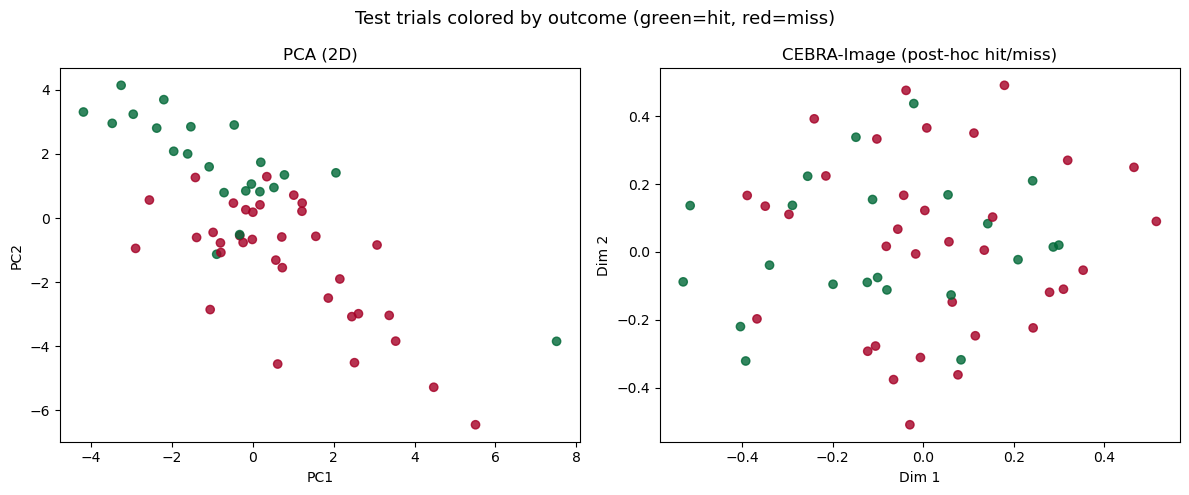

In [28]:
# --- Embedding comparison plot ---------------------------------------------

has_beh = "Z_test_beh_trial" in globals()

if has_beh:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PCA
axes[0].scatter(
    pca_test[:, 0], pca_test[:, 1],
    c=y_test, cmap="RdYlGn", alpha=0.8
)
axes[0].set_title("PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

plot_idx = 1

# Existing hit/miss CEBRA, if available
if has_beh:
    axes[1].scatter(
        Z_test_beh_trial[:, 0], Z_test_beh_trial[:, 1],
        c=y_test, cmap="RdYlGn", alpha=0.8
    )
    axes[1].set_title("CEBRA-Behavior (hit/miss labels)")
    axes[1].set_xlabel("Dim 1")
    axes[1].set_ylabel("Dim 2")
    plot_idx = 2

# Image-trained CEBRA
axes[plot_idx].scatter(
    Z_test_img_trial[:, 0], Z_test_img_trial[:, 1],
    c=y_test, cmap="RdYlGn", alpha=0.8
)
axes[plot_idx].set_title("CEBRA-Image (post-hoc hit/miss)")
axes[plot_idx].set_xlabel("Dim 1")
axes[plot_idx].set_ylabel("Dim 2")

plt.suptitle("Test trials colored by outcome (green=hit, red=miss)", fontsize=13)
plt.tight_layout()
plt.show()

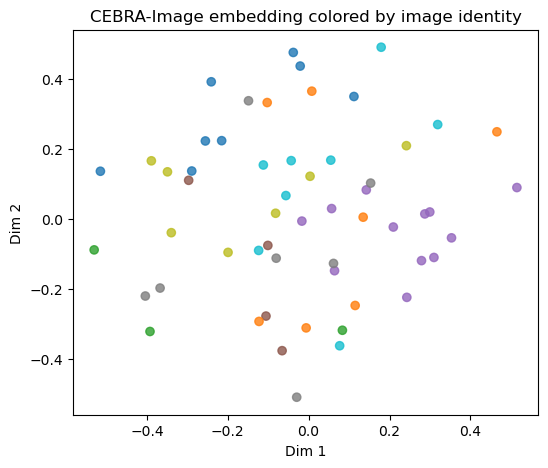

In [29]:
# --- CEBRA-Image embedding colored by image identity -----------------------

plt.figure(figsize=(6, 5))
plt.scatter(
    Z_test_img_trial[:, 0], Z_test_img_trial[:, 1],
    c=img_test, cmap="tab10", alpha=0.8
)
plt.title("CEBRA-Image embedding colored by image identity")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()